<a href="https://colab.research.google.com/github/Melisaoktavia/TugasTranformasiGeometrik_Minggu3/blob/main/PCD_MGG3_TGS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload 2 gambar: (1) Referensi lurus, (2) Gambar miring)


Saving download (6).jpg to download (6).jpg
Saving download (5).jpg to download (5).jpg


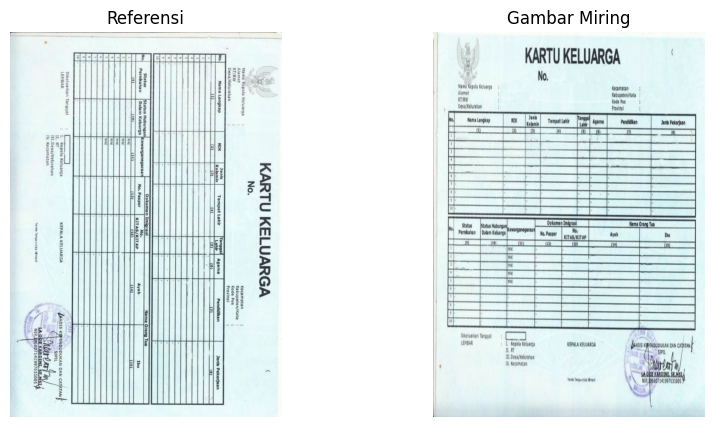


===== HASIL EVALUASI =====

Affine:
MSE : 10632.118
PSNR: 7.864606
Waktu: 0.00831 detik

Perspective - Nearest:
MSE : 3882.784
PSNR: 12.239371
Waktu: 0.01176 detik

Perspective - Bilinear:
MSE : 3743.9788
PSNR: 12.3974695
Waktu: 0.01432 detik

Perspective - Bicubic:
MSE : 3889.7031
PSNR: 12.231638
Waktu: 0.03717 detik


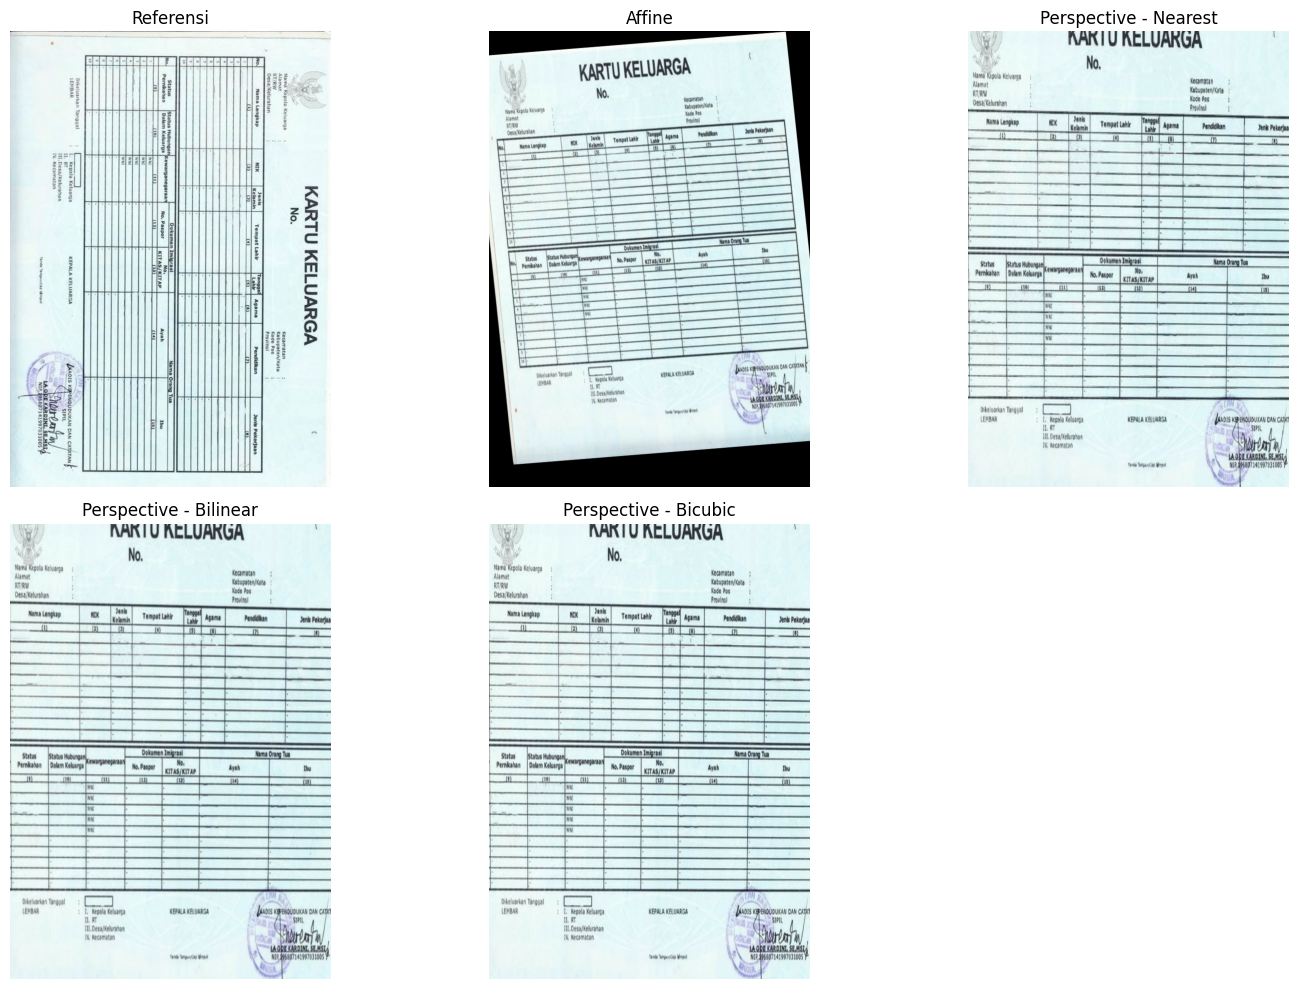

In [7]:
# ============================================================
# PIPELINE TRANSFORMASI GEOMETRIK UNTUK REGISTRASI CITRA
# ============================================================

!pip install opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from google.colab import files

# ============================================================
# 1. UPLOAD GAMBAR
# ============================================================

print("Upload 2 gambar: (1) Referensi lurus, (2) Gambar miring)")
uploaded = files.upload()

images = []
for file in uploaded.keys():
    img = cv2.imread(file)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

if len(images) < 2:
    raise ValueError("Anda harus upload 2 gambar!")

img_ref = images[0]
img_move = images[1]

# Samakan ukuran agar evaluasi valid
h, w = img_ref.shape[:2]
img_move = cv2.resize(img_move, (w, h))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_ref)
plt.title("Referensi")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_move)
plt.title("Gambar Miring")
plt.axis("off")
plt.show()

# ============================================================
# 2. TRANSFORMASI AFFINE (3 TITIK)
# ============================================================

rows, cols = img_move.shape[:2]

pts1_aff = np.float32([[50,50],
                       [cols-50,50],
                       [50,rows-50]])

pts2_aff = np.float32([[10,100],
                       [cols-100,50],
                       [100,rows-100]])

M_affine = cv2.getAffineTransform(pts1_aff, pts2_aff)

start = time.time()
affine_result = cv2.warpAffine(img_move, M_affine, (cols, rows), flags=cv2.INTER_LINEAR)
time_affine = time.time() - start

# ============================================================
# 3. TRANSFORMASI PERSPEKTIF (4 TITIK)
# ============================================================

pts1 = np.float32([[60,60],
                   [cols-60,50],
                   [50,rows-60],
                   [cols-50,rows-50]])

pts2 = np.float32([[0,0],
                   [cols,0],
                   [0,rows],
                   [cols,rows]])

M_persp = cv2.getPerspectiveTransform(pts1, pts2)

# ============================================================
# 4. INTERPOLASI PERSPEKTIF
# ============================================================

# Nearest
start = time.time()
nearest = cv2.warpPerspective(img_move, M_persp, (cols,rows), flags=cv2.INTER_NEAREST)
time_nearest = time.time() - start

# Bilinear
start = time.time()
bilinear = cv2.warpPerspective(img_move, M_persp, (cols,rows), flags=cv2.INTER_LINEAR)
time_bilinear = time.time() - start

# Bicubic
start = time.time()
bicubic = cv2.warpPerspective(img_move, M_persp, (cols,rows), flags=cv2.INTER_CUBIC)
time_bicubic = time.time() - start

# ============================================================
# 5. METRIK EVALUASI
# ============================================================

def mse(img1, img2):
    return np.mean((img1.astype("float32") - img2.astype("float32")) ** 2)

def psnr(img1, img2):
    mse_val = mse(img1, img2)
    if mse_val == 0:
        return 100
    return 20 * np.log10(255.0 / np.sqrt(mse_val))

print("\n===== HASIL EVALUASI =====")

print("\nAffine:")
print("MSE :", mse(img_ref, affine_result))
print("PSNR:", psnr(img_ref, affine_result))
print("Waktu:", round(time_affine,5), "detik")

print("\nPerspective - Nearest:")
print("MSE :", mse(img_ref, nearest))
print("PSNR:", psnr(img_ref, nearest))
print("Waktu:", round(time_nearest,5), "detik")

print("\nPerspective - Bilinear:")
print("MSE :", mse(img_ref, bilinear))
print("PSNR:", psnr(img_ref, bilinear))
print("Waktu:", round(time_bilinear,5), "detik")

print("\nPerspective - Bicubic:")
print("MSE :", mse(img_ref, bicubic))
print("PSNR:", psnr(img_ref, bicubic))
print("Waktu:", round(time_bicubic,5), "detik")

# ============================================================
# 6. VISUALISASI HASIL
# ============================================================

plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(img_ref)
plt.title("Referensi")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(affine_result)
plt.title("Affine")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(nearest)
plt.title("Perspective - Nearest")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(bilinear)
plt.title("Perspective - Bilinear")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(bicubic)
plt.title("Perspective - Bicubic")
plt.axis("off")

plt.tight_layout()
plt.show()
